##### Machine Learning LAB 1: MODEL SELECTION

Course 2025/26: *F. Chiariotti*

The notebook contains a simple learning task over which we will implement **MODEL SELECTION AND VALIDATION**.

Complete all the **required code sections** and **answer all the questions**.

### IMPORTANT for the exam:

The functions you might be required to implement in the exam will have the same signature and parameters as the ones in the labs

## Polynomial Classification on Signal to Noise Ratios

In this notebook we are going to explore the use of polynomial classification with polynomial regression. We are going to use the Numpy **polyfit** function, which performs polynomial regression.

Our use case is a communication problem: we have a set of measurements of the Signal to Noise Ratio (SNR), i.e., the quality of the communication link, in various positions. The SNR depends on two components: firstly, the noise level (which is a random variable that does not depend on position) and the signal attenuation (usually modeled as a polynomial function of the distance).

Our transmitter is in (0,0), and coordinates are in meters. In urban scenarios, the attenuation usually follows a third-degree polynomial, but it might be a fourth- or fifth-degree polynomial in more complex cases. How do we choose between different degrees? We will try with a maximum of **6**

---

## Import all the necessary Python libraries

In [108]:
import numpy as np
import scipy as sp
import pandas as pd
import itertools
from matplotlib import pyplot as plt

---

## Load the data

In this case, x and y are the two coordinates, and the SNR is the thing we are trying to predict

**DO NOT CHANGE THE PRE-WRITTEN CODE UNLESS OTHERWISE SPECIFIED**

In [109]:
df = pd.read_csv('data/snr_measurements.csv',sep=';')
x = df['x'].to_numpy()
y = df['y'].to_numpy()
SNR = df['SNR'].to_numpy()

In [110]:
df

,x,y,SNR
0,40.238833,4.265986,10.175131
1,98.283520,37.818614,3.825913
2,40.218399,70.433962,7.657508
3,62.067195,72.951305,4.979963
4,15.436981,22.427707,11.729007
...,...,...,...
195,69.378761,66.693153,8.378318
196,0.980225,93.372566,6.496289
197,84.321334,81.095003,4.036931
198,92.233200,48.454827,4.672679


## Helper functions

These functions will help us evaluate the results

In [111]:
def compute_distance(x, y):
    # TODO: Compute the Euclidean distance from the origin
    distance = np.sqrt(x**2+y**2)
    return distance

def fit(distance, SNR, degree):
    return np.polyfit(distance, SNR, deg=degree)

def predict(distance, poly_coeffs):
    # Predict the SNR from a given model
    return np.polyval(poly_coeffs,distance)

def evaluate(distance, SNR, poly_coeffs):
    # TODO: Compute the error of the polynomial fit on the chosen data
    prediction = predict(distance,poly_coeffs)
    mse = np.mean((prediction - SNR)**2)
    return mse

def separate_test(distance, SNR, test_points):
    # TODO: Return a training set and a test set (the test_points parameter controls the number of test points).
    # The points should be selected randomly
    idx = np.random.permutation(len(distance))  # 1. Shuffle positions
    
    ts, tr = idx[:test_points], idx[test_points:]
    return distance[tr], SNR[tr], distance[ts], SNR[ts]

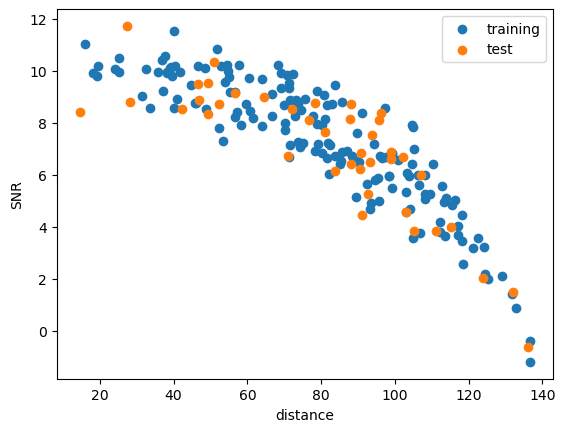

In [112]:
# TODO: separate the training and test sets and create a scatter plot of the SNR as a function of the distance
distance = compute_distance(x,y)

train_x, train_y, test_x, test_y = separate_test(distance, SNR, test_points=40)

plt.scatter(train_x, train_y, label= "training")
plt.scatter(test_x, test_y , label= "test")
plt.xlabel("distance")
plt.ylabel("SNR")
plt.legend()
plt.show()

## A. K-fold cross-validation

In this case, x and y are the two coordinates, and the SNR is the thing we are trying to predict

In [91]:
# Function to perform the K-fold cross validation
def k_fold_cross_validation(x_train: np.ndarray, y_train: np.ndarray, k: int, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: Perform K-fold cross-validation on the training set.
    # The two returned values are the best model and the list of results for all degrees up to max_degree.
    # The points should be selected randomly.
    # The inputs and labels are already in terms of distance and SNR
    idx = np.random.permutation(len(x_train))
    folds = np.array_split(idx,k)

    
    results, best, best_err = [], 0, np.inf

    for deg in range(max_degree + 1):
        errs = []

        for i in range(k):
            val_idx = folds[i]
            train_idx = np.concatenate(folds[:i] + folds[i+1:])

            model = fit(x_train[train_idx], y_train[train_idx], deg)
            error = evaluate(x_train[val_idx], y_train[val_idx], model)
            errs.append(error)

        loss = np.mean(errs)
        results.append(loss)

        if loss < best_err:
            best_err = loss
            best = fit(x_train, y_train, deg)

    return best, results

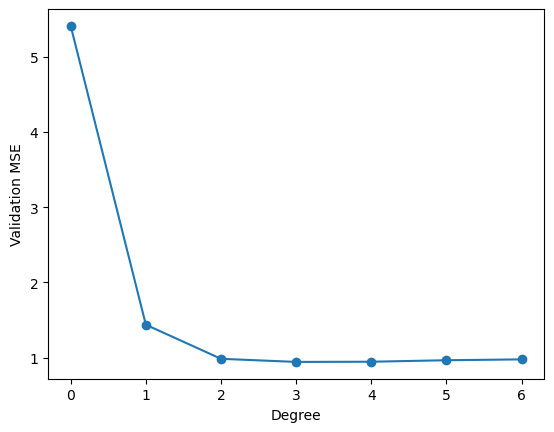

In [93]:
# TODO: run the training with K-fold cross-validation with 40 test points and 4 folds Plot the validation score as a function of the degree
distance = compute_distance(x, y)
x_train, y_train, x_test, y_test = separate_test(distance, SNR, 40)

best_model, results = k_fold_cross_validation(x_train, y_train, 4, 6)

plt.plot(range(7), results, "o-")
plt.xlabel("Degree")
plt.ylabel("Validation MSE")
plt.show()

Best degree: 3
Test MSE: 0.9666171778318073


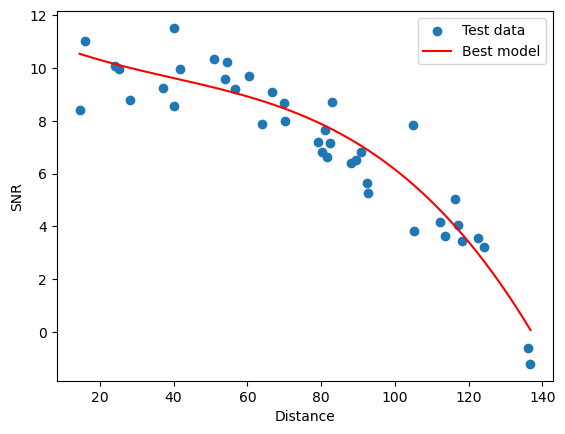

In [94]:
# TODO: get the test performance of the best model and plot the model output and test points. 
# Try running the program multiple times, changing the values of K and the number of test points: is the output always the same?
print("Best degree:", len(best_model)-1)
print("Test MSE:", evaluate(x_test, y_test, best_model))

x_plot = np.linspace(distance.min(), distance.max(), 200)

plt.scatter(x_test, y_test, label="Test data")
plt.plot(x_plot, predict(x_plot, best_model), "r-", label="Best model")
plt.xlabel("Distance")
plt.ylabel("SNR")
plt.legend()
plt.show()

---

## B. Tikhonov regularization

Change the loss function to include a Tikhonov regularization term, as an alternative to cross-validation (try $\lambda=0.01$)

In [68]:
def evaluate_tikhonov(x_train: np.ndarray, y_train: np.ndarray, lambda_par: float, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: apply Tikhonov regularization AFTER the fitting process
    results, best, best_err = [], 0, np.inf
    for deg in range(max_degree+1):
        model = np.polyfit(x_train, y_train, deg)
        loss = evaluate(x_train, y_train, model) + lambda_par * np.sum(model**2)
        results.append(loss)
        if loss < best_err:
            best_err, best = loss, model

    return best, results

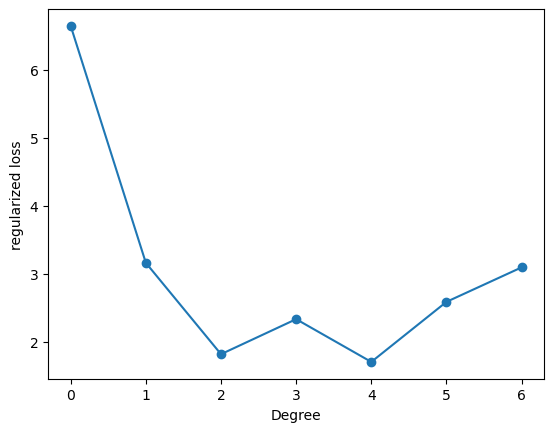

In [84]:
# TODO: run the training with Tikhonov regularization and plot the loss as a function of the degree
best, results = evaluate_tikhonov(x_train, y_train, 0.01, 6)

plt.plot(range(7), results, "o-")
plt.xlabel("Degree")
plt.ylabel("regularized loss")
plt.show()

## C. Minimum description length regularization

Change the loss function to include a representation length regularization term, as an alternative to cross-validation. The minimum description length of a polynomial of degree N is O(2^N) - try $\lambda=0.02$

In [85]:
def evaluate_representation(x_train: np.ndarray, y_train: np.ndarray, lambda_par: float, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: apply Tikhonov regularization AFTER the fitting process
    results, best, best_err = [], 0, np.inf
    for deg in range(max_degree+1):
        model = np.polyfit(x_train, y_train, deg)
        loss = evaluate(x_train, y_train, model) + lambda_par * (2**(deg+1))
        results.append(loss)
        if loss < best_err:
            best_err, best = loss, model

    return best, results

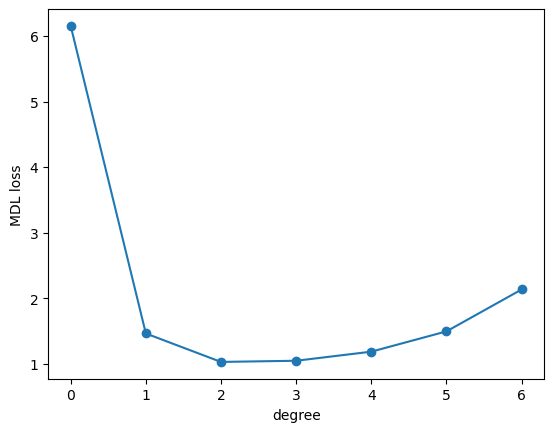

In [89]:
# TODO: run the training with MDL regularization and plot the loss as a function of the degree
best, results = evaluate_representation(x_train, y_train, 0.01, 6)

plt.plot(range(7), results, "o-")
plt.xlabel("degree")
plt.ylabel("MDL loss")
plt.show()

### TEST

Check the performance of the three solutions on the test set: which one does best?


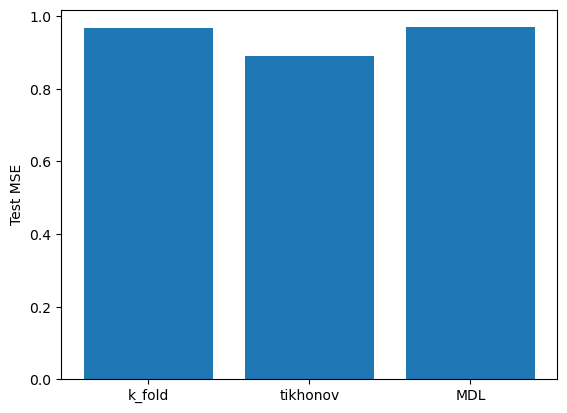

the best: tikhonov


In [113]:
# TODO: plot the results
best, _ = k_fold_cross_validation(x_train, y_train, 4, 6)

best_1, _ = evaluate_tikhonov(x_train, y_train, 0.01, 6)

best_2, _ = evaluate_representation(x_train, y_train, 0.01, 6)

names = ["k_fold", "tikhonov", "MDL"]
errs = [evaluate(x_test, y_test, best), evaluate(x_test, y_test, best_1), evaluate(x_test, y_test, best_2)]

plt.bar(names, errs)
plt.ylabel("Test MSE")
plt.show()

print("the best:", names[np.argmin(errs)])